### setup

In [1]:
%matplotlib inline

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import Image, display

# dataset dirs follow conf/dataset/*/default.yaml: ${root}/${dataset.dir}
DATA = Path('/home/nik/workspace/ImperialWork/msc_project/SyncNetProject/data')
SOC_NPZ = DATA / 'sort_of_clevr-seed1-train36000-test1000-q10-t-1' / 'test.npz'
SQOOP_NPZ = DATA / 'sqoop-seed0-train1080000-test25600-rhs18' / 'val_seen.npz'

OUT_DIR = Path('./outputs') / 'figures'
CHAP_DATASETS = OUT_DIR / 'chap:datasets'
CHAP_RESULTS = OUT_DIR / 'chap:results'
CHAP_DATASETS.mkdir(parents=True, exist_ok=True)
CHAP_RESULTS.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 140,
    'savefig.dpi': 400,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
})


def save_show(fig, name, dir, screen_dpi=110):
    path = dir / f'{name}.png'
    fig.savefig(path)
    # display at screen size rather than the 400-dpi saved pixel size
    width = int(fig.get_size_inches()[0] * screen_dpi)
    plt.close(fig)
    display(Image(path, width=width))

### Sort-of-CLEVR example

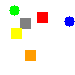

In [2]:
soc = np.load(SOC_NPZ, allow_pickle=False)

scene = 0
plt.imsave(CHAP_DATASETS / 'soc_example.png', soc['images'][scene][..., ::-1])   # stored BGR (cv2)
display(Image(CHAP_DATASETS / 'soc_example.png'))

### SQOOP examples

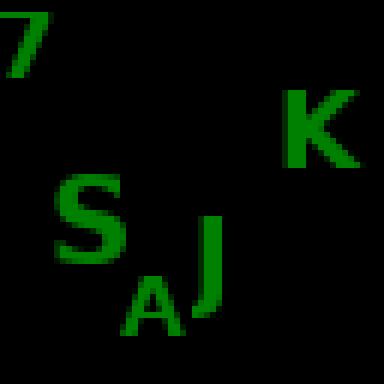

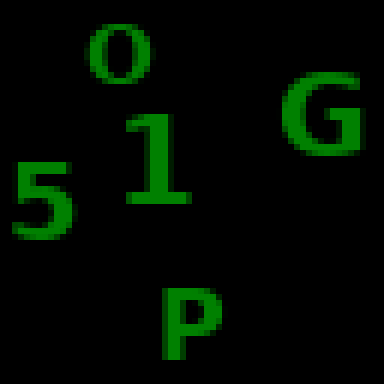

In [3]:
sq = np.load(SQOOP_NPZ, allow_pickle=True)

for i in range(2):
    plt.imsave(CHAP_DATASETS / f'sqoop_example_{i}.png', np.kron(sq['images'][i], np.ones((6, 6, 1), dtype=np.uint8)))
    display(Image(CHAP_DATASETS / f'sqoop_example_{i}.png'))

### results — run registry

Every result cell in the thesis is one `cfg_hash` (the 10-char id in the `cfg:…` tag / `config.cfg_hash`;
identical configs share a hash, so seeded reruns of a cell aggregate automatically). Edit the hashes
here and nothing else needs to change. `None` = not run yet, and that cell is simply left out of the
figures. A cell may also be a *list* of hashes if you want to pool runs from configs you consider equivalent.

Model labels are the legend labels. The sweep ablations (`t_train`, `n_modules`, `phase_dim`) map an x-value to a hash.
`t_test` is a single hash: the test-time-T sweep comes from the `t_variance/*` summaries of that run,
so it needs the `t_variance` callback enabled.

In [ ]:
ENTITY = 'niks_priv'
PROJECT = {'sort_of_clevr': 'sort_of_clevr', 'sqoop': 'sqoop'}
TAG = 'v16'          # only runs carrying this tag are fetched
PAIR_VARIETY = [1, 2, 4, 8, 18, 35]

# ---------------------------------------------------------------- main tables
MAIN = {
    'sort_of_clevr': {                       # label -> cfg_hash
        'Q-Only':      None,
        'Conv+LSTM':   None,
        'RelNet':      None,
        'FiLM':        None,
        'Transformer': None,
        'Workspace':   None,
        'SyncNet':     '28033fa5ab',         # sync/hybrids/identity_spatial  (6 seeds)
    },
    'sqoop': {                               # label -> {pair variety -> cfg_hash}
        'Q-Only':      {1: 'da868e47f3', 2: '8c385b2059', 4: 'b53f5ecb08', 8: 'c7cfb0dd1c', 18: 'd640141c57', 35: 'a09acf017b'},
        'Conv+LSTM':   {1: '4dd2f8a5f6', 2: 'b838865278', 4: '11380cec6a', 8: '125ce8d50e', 18: '6828367e4c', 35: 'd6cbb5b004'},
        'RelNet':      {1: 'd91b42c323', 2: '41515ce582', 4: '46ef70288f', 8: 'f15b7d0159', 18: 'fd877702cb', 35: '18a92d8762'},
        'FiLM':        {1: '48c351e38b', 2: 'cbbfbd61a7', 4: '13e08caaa4', 8: '70f71488ff', 18: '4cf87adb37', 35: 'dd57cc6026'},
        'Transformer': {1: 'e5acac883a', 2: 'bd94a19a03', 4: '10eb8e1433', 8: '007a9674ee', 18: '17110fa882', 35: '13222c0aab'},
        'Workspace':   {1: '58a944c267', 2: '61a49532b2', 4: 'd12abb2e78', 8: 'fe996cfc81', 18: 'f3743655aa', 35: 'fa00371d63'},
        'SyncNet':     {1: None,         2: None,         4: None,         8: None,         18: '9f0c939a32', 35: None},
        #               sync/hybrids/identity_partition_cnnenc (3 seeds at rhs 18)
    },
}

# floor for "accuracy above floor" plots (None -> plot raw accuracy)
FLOOR_MODEL = {'sort_of_clevr': 'Q-Only', 'sqoop': None}

# ------------------------------------------------------------------ ablations
ABLATIONS = {
    'sort_of_clevr': {
        # sweeps: x -> cfg_hash.  Canonical value is read from the main run's config.
        't_train':   {1: None, 2: None, 4: None, 6: None, 8: '28033fa5ab', 12: None},
        'n_modules': {1: None, 2: None, 4: None, 6: '28033fa5ab', 8: None, 12: None},
        'phase_dim': {2: None, 3: None, 4: None, 6: '28033fa5ab', 8: None, 12: None},
        # test-time T sweep: one hash, values from t_variance/*_mean_T{T}
        't_test':    '28033fa5ab',
    },
}

T_TEST = [0, 1, 2, 4, 6, 8, 12, 16]           # the T values the t_variance callback evaluates
FAMILIES = ['Overall', 'Non-relational', 'Binary', 'Ternary']


### results — pull runs from wandb

`fetch_runs` pulls every `TAG`-tagged run of a project through the API (config flattened to `model.name`-style
keys, every scalar summary) into a plain DataFrame, one row per run, held in `RUNS`.
Re-running the cell reuses `RUNS` unless `REFRESH = True`. If the API is unreachable it falls back to the newest `wandb_export_*.csv`
next to the notebook (the export button truncates columns, so prefer the API).

In [ ]:
REFRESH = False


def _flatten(d, prefix=''):
    out = {}
    for k, v in d.items():
        if k.startswith('_'):
            continue
        key = f'{prefix}{k}'
        if isinstance(v, dict):
            out.update(_flatten(v, key + '.'))
        else:
            out[key] = json.dumps(v) if isinstance(v, (list, tuple)) else v
    return out


def _from_api(project):
    import wandb
    api = wandb.Api(timeout=120)
    rows = []
    for r in api.runs(f'{ENTITY}/{project}', filters={'tags': TAG}):
        row = {'run_id': r.id, 'Name': r.name, 'State': r.state,
               'Created': str(r.created_at), 'Tags': ', '.join(r.tags)}
        row.update(_flatten(r.config))
        row.update({k: v for k, v in r.summary.items()
                    if isinstance(v, (int, float, str, bool)) and not k.startswith('_')})
        rows.append(row)
    return pd.DataFrame(rows)


def _from_export(project):
    cands = sorted(Path('.').glob('wandb_export_*.csv'), key=lambda p: p.stat().st_mtime)
    for p in reversed(cands):
        df = pd.read_csv(p, low_memory=False)
        if 'dataset.name' in df and (df['dataset.name'] == project).any():
            print(f'  {project}: using export {p.name}')
            return df[df['dataset.name'] == project].copy()
    raise FileNotFoundError(f'no wandb export found for {project}')


def _normalise(df):
    """One row per run; add cfg_hash / seed / variety columns and drop dupes."""
    df = df.copy()
    if 'cfg_hash' not in df:
        df['cfg_hash'] = np.nan
    from_tags = df['Tags'].astype(str).str.extract(r'cfg:([0-9a-f]{10})')[0]
    df['cfg_hash'] = df['cfg_hash'].fillna(from_tags)
    df['seed'] = df['train.seed'].astype('Int64')
    df['variety'] = df['dataset.rhs_variety'].astype('Int64') if 'dataset.rhs_variety' in df else pd.NA
    df = df[df['State'] == 'finished']
    # keep the most recent finished run per (cfg, seed)
    df = df.sort_values('Created').drop_duplicates(['cfg_hash', 'seed'], keep='last')
    return df.reset_index(drop=True)


def fetch_runs(dataset):
    project = PROJECT[dataset]
    try:
        raw = _from_api(project)
        print(f'  {project}: {len(raw)} runs from API')
    except Exception as e:                      # offline / no key
        warnings.warn(f'wandb API failed for {project} ({e!r}); falling back to CSV export')
        raw = _from_export(project)
    raw = raw.loc[:, ~raw.columns.duplicated()]
    return _normalise(raw)


# RUNS lives in the kernel only; re-running this cell re-fetches when REFRESH is True or RUNS is missing
if REFRESH or 'RUNS' not in globals():
    RUNS = {ds: fetch_runs(ds) for ds in PROJECT}
for ds, df in RUNS.items():
    print(f'{ds}: {len(df)} finished runs, {df.cfg_hash.nunique()} configs')


### results — build the results table

`TABLE` is the single long table every figure reads: one row per *(figure, dataset, series, x, seed, metric)*.
`SUMMARY` aggregates it to mean / sd / n. The coverage printout at the end shows which registry cells
have how many seeds, and which are still empty.
The two main tables (Sort-of-CLEVR by question family, SQOOP by split × pair variety) are shown below.

In [ ]:
METRICS = {
    'sort_of_clevr': {'Overall': 'test_callbacks/accuracy',
                      'Non-relational': 'test_callbacks/non_relational_accuracy',
                      'Binary': 'test_callbacks/binary_accuracy',
                      'Ternary': 'test_callbacks/ternary_accuracy'},
    'sqoop': {'validation': 'eval_callbacks/accuracy',
              'held-out': 'test_callbacks/accuracy'},
}
T_VARIANCE = {'Overall': 't_variance/acc_mean_T{}',
              'Binary': 't_variance/binary_mean_T{}',
              'Ternary': 't_variance/ternary_mean_T{}'}


def runs_for(dataset, hashes):
    """Finished runs matching one hash or a list of hashes (None -> empty)."""
    if hashes is None:
        return RUNS[dataset].iloc[0:0]
    hashes = [hashes] if isinstance(hashes, str) else list(hashes)
    return RUNS[dataset][RUNS[dataset].cfg_hash.isin(hashes)]


def _rows(figure, dataset, series, x, hashes, metrics):
    df = runs_for(dataset, hashes)
    for _, r in df.iterrows():
        for metric, col in metrics.items():
            if col in r and pd.notna(r[col]):
                yield dict(figure=figure, dataset=dataset, series=series, x=x,
                           cfg_hash=r.cfg_hash, seed=int(r.seed), run_id=r.get('run_id', r['Name']),
                           metric=metric, value=100 * float(r[col]))


def build_table():
    rows = []
    # main tables
    for label, h in MAIN['sort_of_clevr'].items():
        rows += _rows('main', 'sort_of_clevr', label, None, h, METRICS['sort_of_clevr'])
    for label, by_v in MAIN['sqoop'].items():
        for v, h in by_v.items():
            rows += _rows('main', 'sqoop', label, v, h, METRICS['sqoop'])
    # sweep ablations (Sort-of-CLEVR)
    for sweep in ('t_train', 'n_modules', 'phase_dim'):
        for x, h in ABLATIONS['sort_of_clevr'][sweep].items():
            rows += _rows(sweep, 'sort_of_clevr', None, x, h, METRICS['sort_of_clevr'])
    # test-time T sweep from the t_variance summaries of the main run
    for T in T_TEST:
        rows += _rows('t_test', 'sort_of_clevr', None, T, ABLATIONS['sort_of_clevr']['t_test'],
                      {fam: col.format(T) for fam, col in T_VARIANCE.items()})
    # joint (train, test) T grid: every t_train run also carries its own t_variance sweep
    for Ttr, h in ABLATIONS['sort_of_clevr']['t_train'].items():
        for Tte in T_TEST:
            rows += _rows('t_grid', 'sort_of_clevr', Ttr, Tte, h,
                          {'Overall': T_VARIANCE['Overall'].format(Tte)})
    cols = ['figure', 'dataset', 'series', 'x', 'cfg_hash', 'seed', 'run_id', 'metric', 'value']
    return pd.DataFrame(rows, columns=cols)


TABLE = build_table()
SUMMARY = (TABLE.groupby(['figure', 'dataset', 'series', 'x', 'metric'], dropna=False)['value']
           .agg(mean='mean', sd=lambda s: s.std(ddof=1), n='count').reset_index())


def _report():
    """Which registry cells are filled, and with how many seeds."""
    def n(ds, h):
        return len(runs_for(ds, h))
    print('MAIN')
    for label, h in MAIN['sort_of_clevr'].items():
        print(f"  sort_of_clevr  {label:<22} {h or '-':<12} seeds={n('sort_of_clevr', h)}")
    for label, by_v in MAIN['sqoop'].items():
        print(f"  sqoop          {label:<22} " + '  '.join(f'v{v}:{n("sqoop", h)}' for v, h in by_v.items()))
    print('ABLATIONS')
    for sweep in ('t_train', 'n_modules', 'phase_dim'):
        print(f"  sort_of_clevr  {sweep:<22} " + '  '.join(f'{x}:{n("sort_of_clevr", h)}' for x, h in ABLATIONS['sort_of_clevr'][sweep].items()))
    nt = int(TABLE[TABLE.figure == 't_test'].seed.nunique())
    print(f"  sort_of_clevr  t_test                 seeds with t_variance={nt}")


_report()


def show_table(dataset):
    """mean ± sd (n) per cell of the main table, straight from TABLE."""
    t = TABLE[(TABLE.figure == 'main') & (TABLE.dataset == dataset)]
    agg = t.groupby(['series', 'x', 'metric'], dropna=False).value.agg(['mean', 'std', 'count'])
    fmt = agg.apply(lambda r: f"{r['mean']:.1f} ± {r['std']:.1f} ({int(r['count'])})", axis=1).rename(dataset)
    if dataset == 'sort_of_clevr':
        out = fmt.droplevel('x').unstack('metric')[list(METRICS[dataset])]
        out = out.reindex(list(MAIN[dataset]))
    else:
        out = fmt.unstack('x')
        out.columns = [f'variety {int(v)}' for v in out.columns]
        out = out.reindex(pd.MultiIndex.from_product([list(MAIN[dataset]), list(METRICS[dataset])], names=['series', 'metric']))
    return out.fillna('—')


display(show_table('sort_of_clevr'))
display(show_table('sqoop'))



def show_table(dataset):
    """mean ± sd (n) per cell of the main table, straight from TABLE."""
    t = TABLE[(TABLE.figure == 'main') & (TABLE.dataset == dataset)]
    agg = t.groupby(['series', 'x', 'metric'], dropna=False).value.agg(['mean', 'std', 'count'])
    fmt = agg.apply(lambda r: f"{r['mean']:.1f} ± {r['std']:.1f} ({int(r['count'])})", axis=1).rename(dataset)
    if dataset == 'sort_of_clevr':
        out = fmt.droplevel('x').unstack('metric')[list(METRICS[dataset])]
        out = out.reindex(list(MAIN[dataset]))
    else:
        out = fmt.unstack('x')
        out.columns = [f'variety {int(v)}' for v in out.columns]
        out = out.reindex(pd.MultiIndex.from_product([list(MAIN[dataset]), list(METRICS[dataset])], names=['series', 'metric']))
    return out.fillna('—')


display(show_table('sort_of_clevr'))
display(show_table('sqoop'))

### results — accessors

Figures only ever go through these two helpers, so they stay agnostic to where the numbers came from.

In [ ]:
def values(figure, dataset, series=None, x=None, metric='Overall'):
    """Per-seed values (np.array, may be empty) for one cell."""
    t = TABLE[(TABLE.figure == figure) & (TABLE.dataset == dataset) & (TABLE.metric == metric)]
    if series is not None:
        t = t[t.series == series]
    if x is not None:
        t = t[t.x == x]
    return t.sort_values('seed').value.to_numpy()


def mean_sd(figure, dataset, series=None, x=None, metric='Overall'):
    v = values(figure, dataset, series, x, metric)
    if len(v) == 0:
        return np.nan, np.nan
    return v.mean(), (v.std(ddof=1) if len(v) > 1 else 0.0)


def floor(dataset, metric='Overall'):
    """Mean accuracy of the floor model, or 0 if no floor is configured / run."""
    fm = FLOOR_MODEL.get(dataset)
    if fm is None:
        return 0.0
    m, _ = mean_sd('main', dataset, fm, None, metric)
    return 0.0 if np.isnan(m) else m


def canon(dataset, key, default=np.nan):
    """Read a config value from the main SyncNet run(s)."""
    df = runs_for(dataset, MAIN[dataset]['SyncNet'] if dataset == 'sort_of_clevr'
                  else MAIN[dataset]['SyncNet'].get(18))
    return df[key].dropna().iloc[0] if key in df and df[key].notna().any() else default


T_CANON = int(canon('sort_of_clevr', 'model.t_bus', 8))
M_CANON = int(canon('sort_of_clevr', 'model.n_modules', 6))
D_CANON = int(canon('sort_of_clevr', 'model.phase_dim', 6))
T_CANON, M_CANON, D_CANON


### results — Sort-of-CLEVR ablation plots

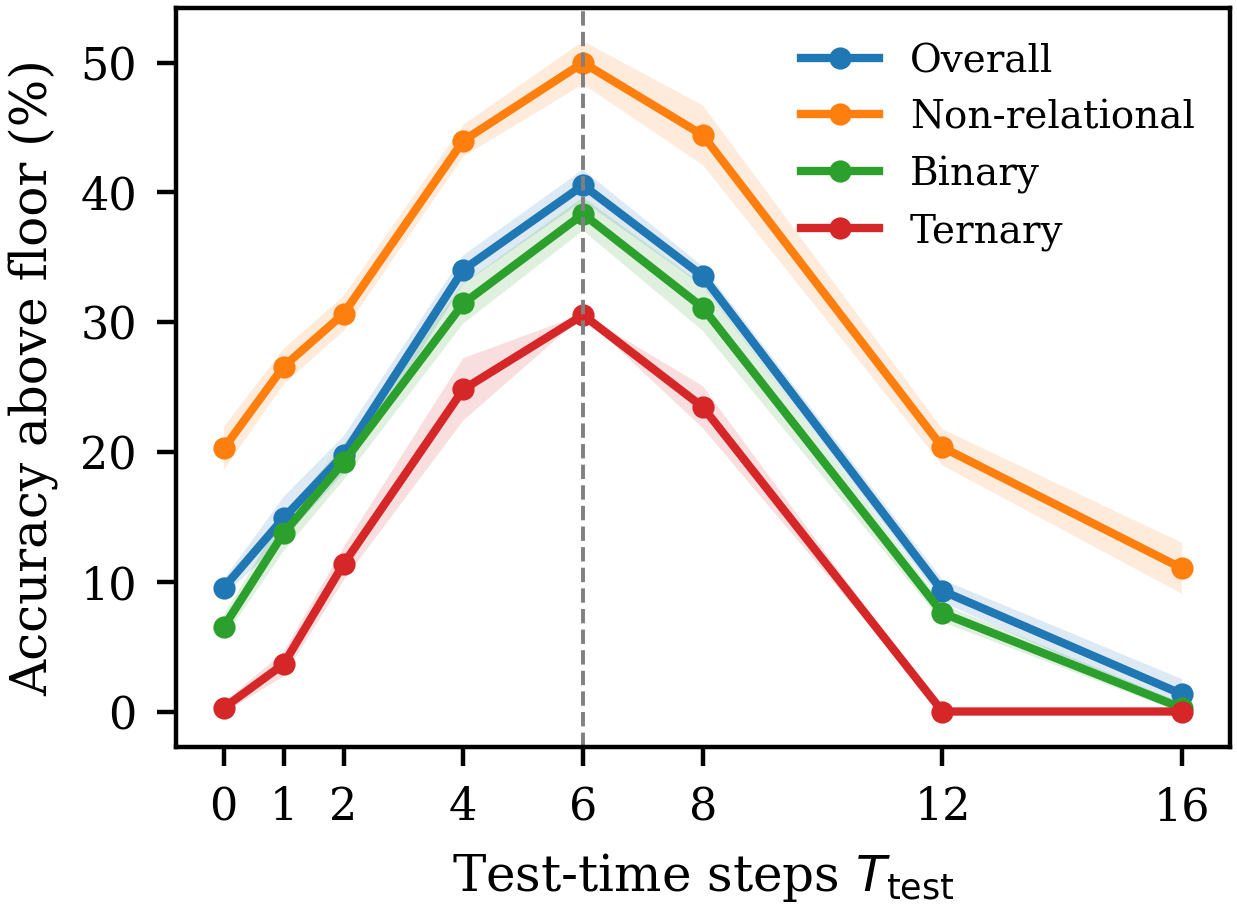

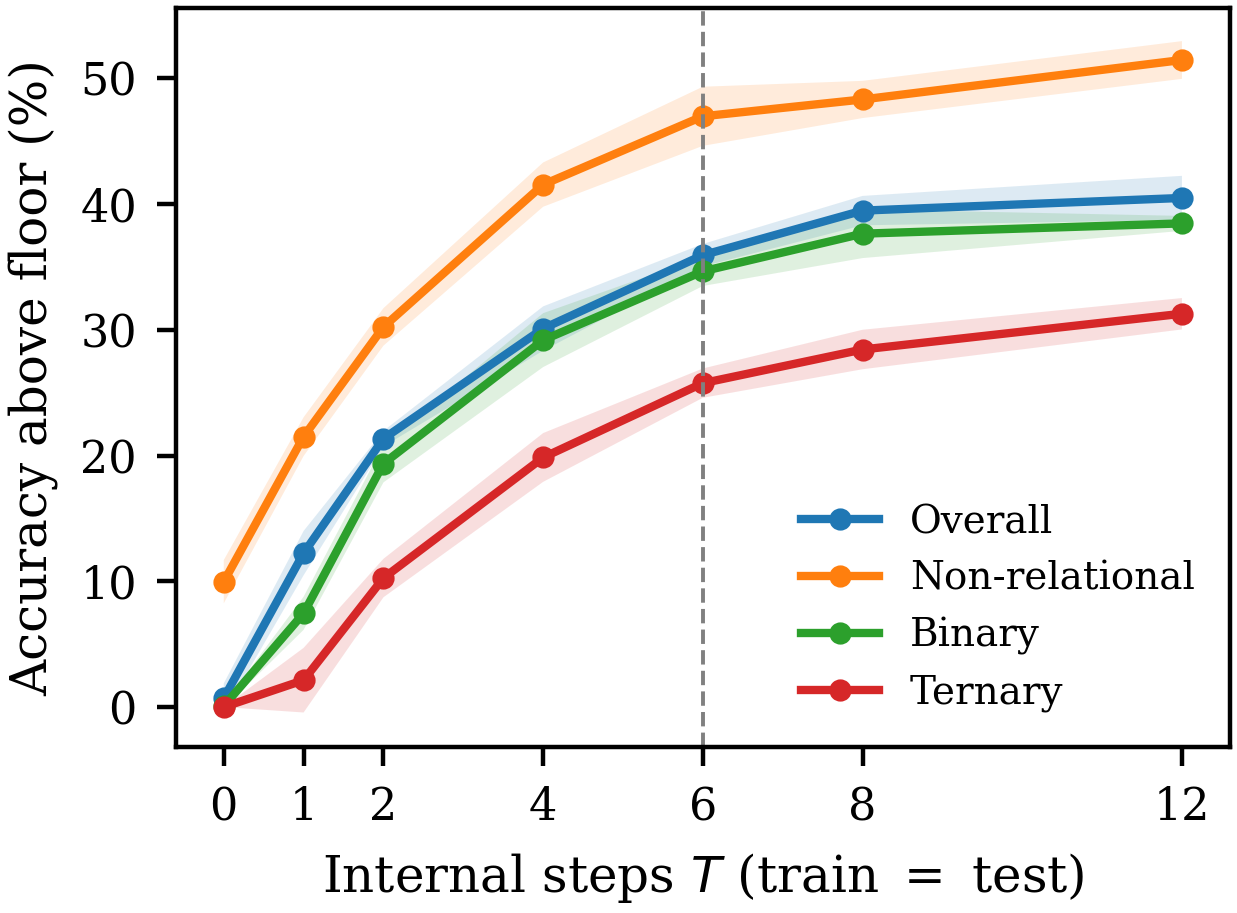

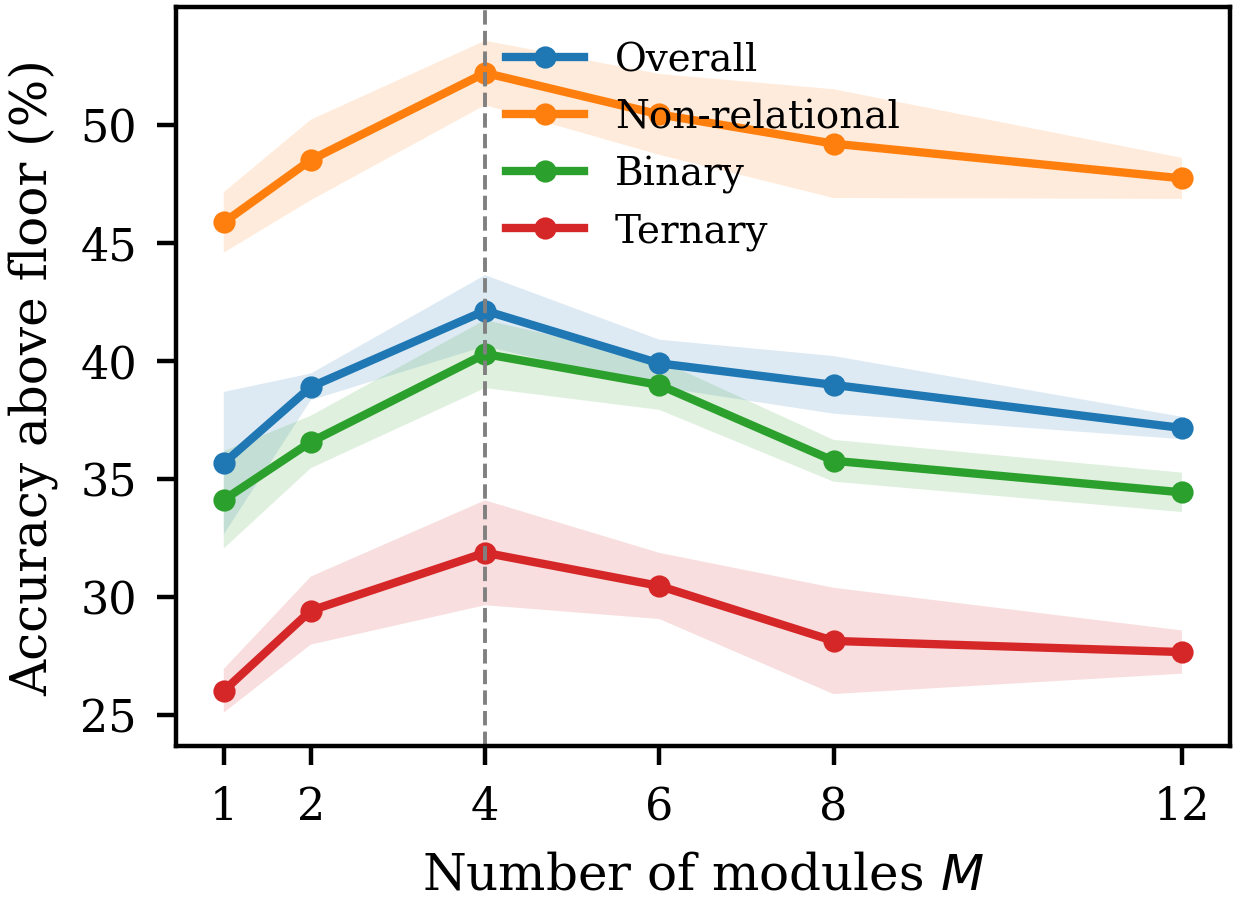

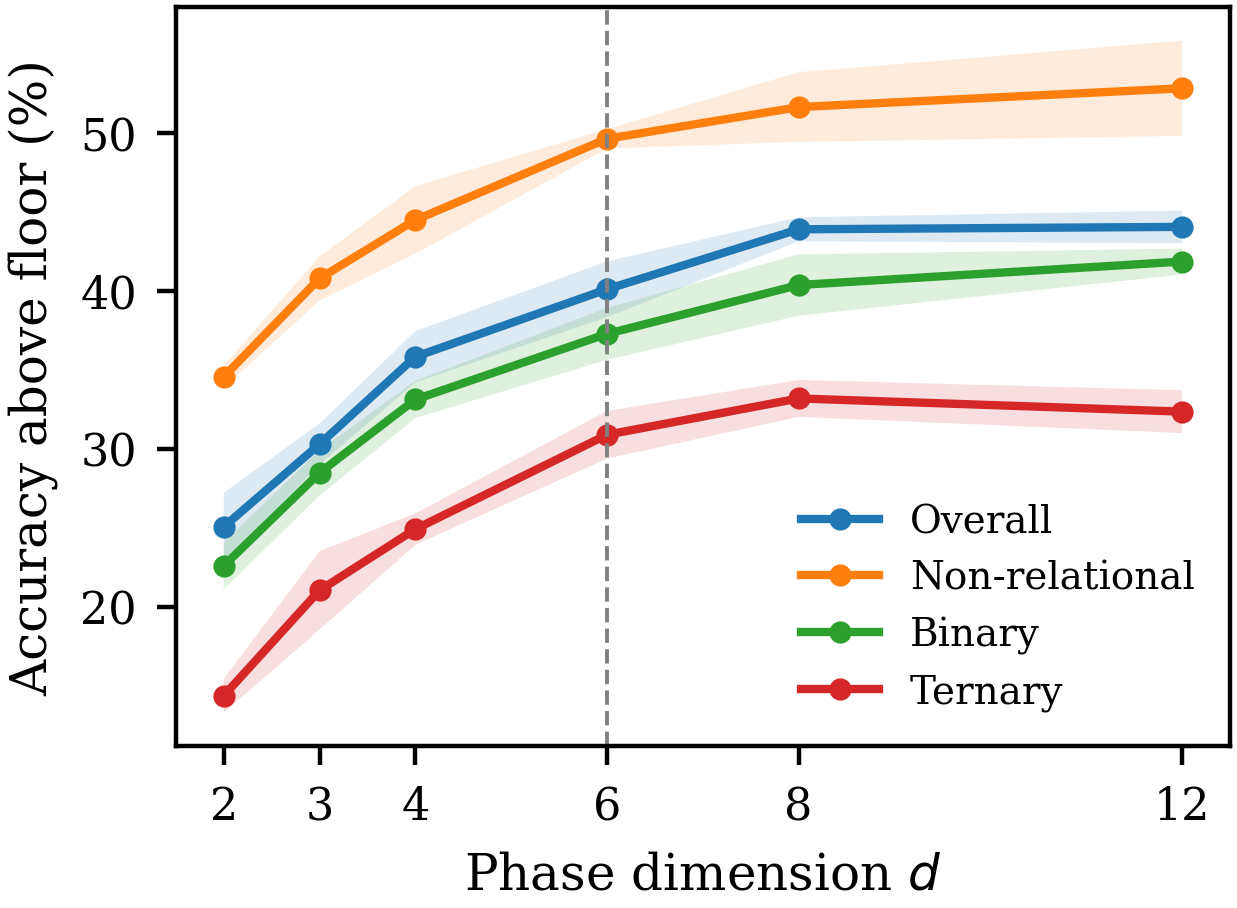

In [5]:
def ablation(figure, xs, xlabel, canon_x, name, above_floor=True):
    """Line-per-family plot of a sweep ablation; cells with no runs are skipped."""
    fig, ax = plt.subplots(figsize=(3.4, 2.4))
    fl = {fam: (floor('sort_of_clevr', fam) if above_floor else 0.0) for fam in FAMILIES}
    plotted = False
    for fam in FAMILIES:
        pts = [(x, *mean_sd(figure, 'sort_of_clevr', None, x, fam)) for x in xs]
        pts = [(x, m - fl[fam], s) for x, m, s in pts if not np.isnan(m)]
        if not pts:
            continue
        plotted = True
        x, m, s = map(np.array, zip(*pts))
        ax.plot(x, m, marker='o', markersize=3, label=fam)
        ax.fill_between(x, m - s, m + s, alpha=0.15)
    ax.axvline(canon_x, color='grey', linestyle='--', linewidth=0.7)
    ax.set_xticks(xs)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy above floor (%)' if above_floor and FLOOR_MODEL['sort_of_clevr'] else 'Accuracy (%)')
    if plotted:
        ax.legend(frameon=False, fontsize=7)
    else:
        ax.text(0.5, 0.5, 'no runs yet', ha='center', va='center', transform=ax.transAxes, color='grey')
    save_show(fig, name, CHAP_RESULTS)


ablation('t_test', T_TEST, r'Test-time steps $T_{\mathrm{test}}$', T_CANON, 'soc_ablation_t_test')
ablation('t_train', list(ABLATIONS['sort_of_clevr']['t_train']), r'Internal steps $T$ (train $=$ test)', T_CANON, 'soc_ablation_t_train')
ablation('n_modules', list(ABLATIONS['sort_of_clevr']['n_modules']), r'Number of modules $M$', M_CANON, 'soc_ablation_n_modules')
ablation('phase_dim', list(ABLATIONS['sort_of_clevr']['phase_dim']), r'Phase dimension $d$', D_CANON, 'soc_ablation_phase_dim')


### results — joint train/test T (3D surface + heatmap)

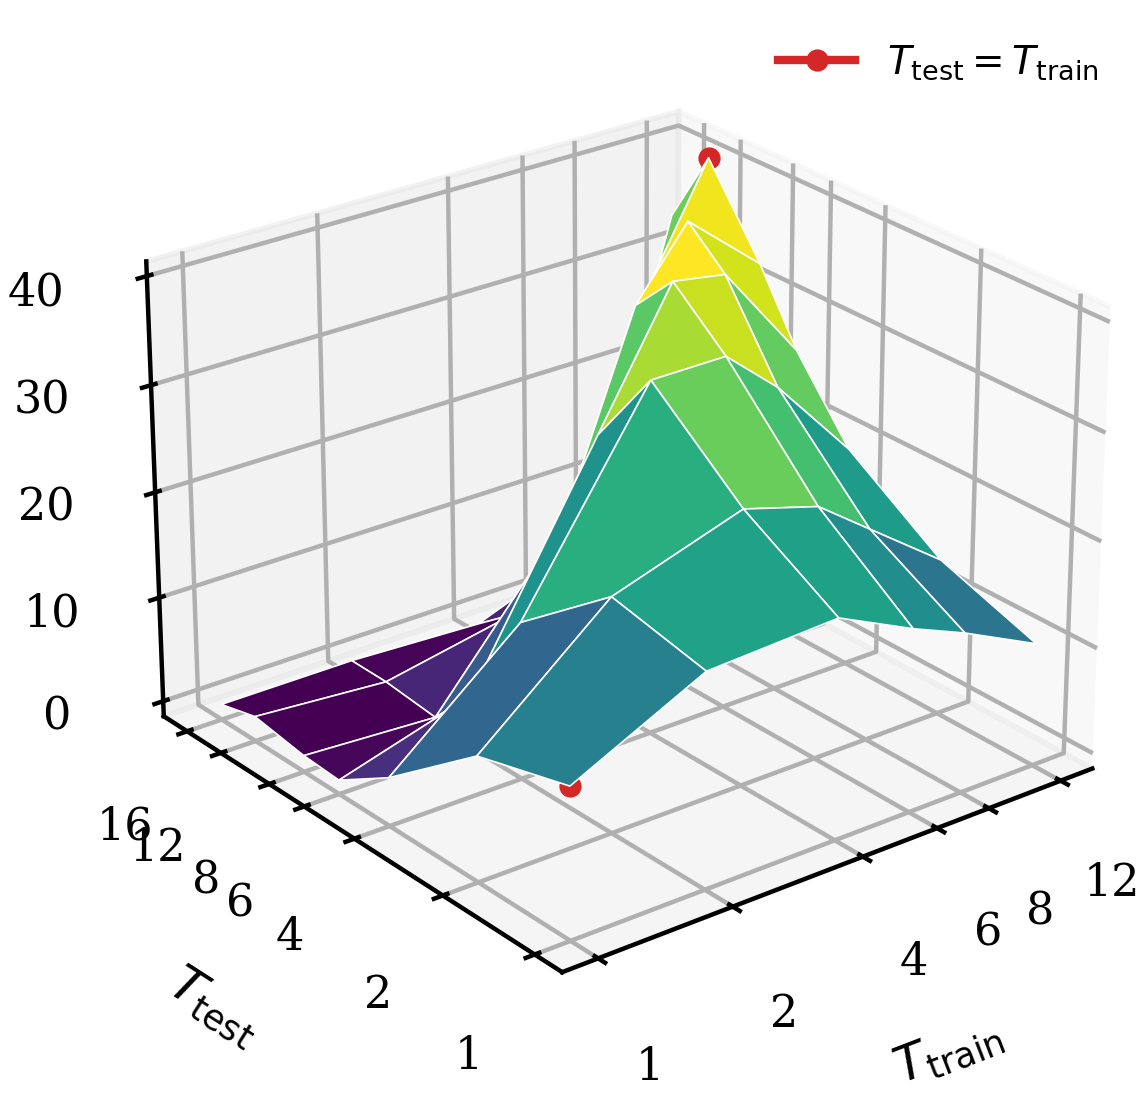

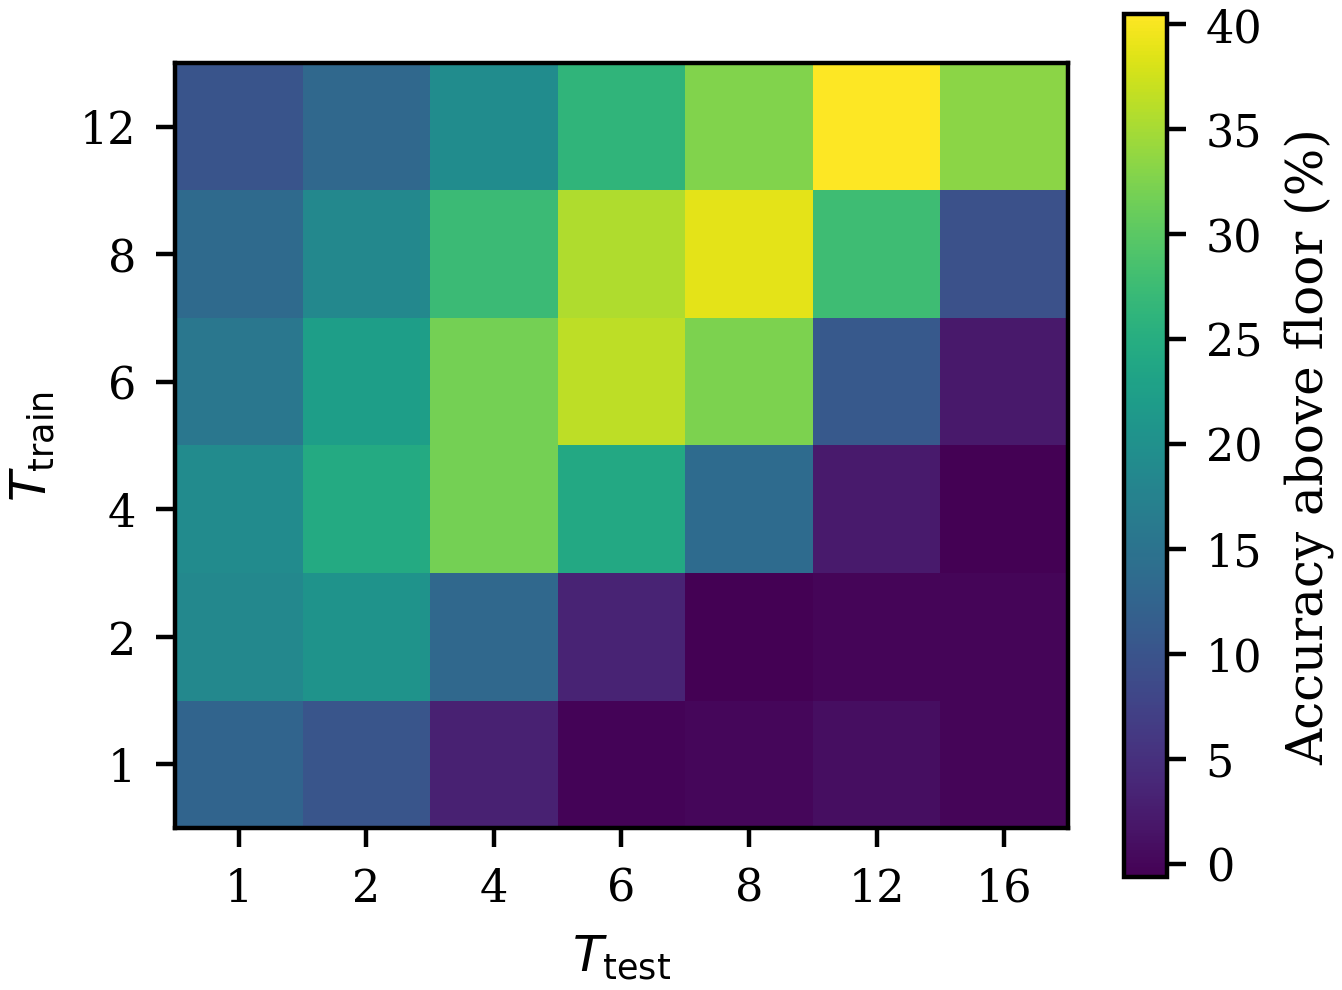

In [6]:
grid = SUMMARY[(SUMMARY.figure == 't_grid') & (SUMMARY.metric == 'Overall')]
tr = sorted(int(v) for v in grid.series.dropna().unique() if int(v) > 0)
te = [t for t in T_TEST if t > 0]

if len(tr) < 2:
    print(f'joint T grid needs t_variance summaries on ≥2 t_train runs (have {len(tr)}) — skipped')
else:
    Z = np.array([[mean_sd('t_grid', 'sort_of_clevr', Ttr, Tte)[0] for Tte in te] for Ttr in tr]) - floor('sort_of_clevr')
    TR, TE = np.meshgrid(np.log2(tr), np.log2(te), indexing='ij')

    fig = plt.figure(figsize=(4.5, 3.4))
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(TR, TE, Z, cmap='viridis', edgecolor='white', linewidth=0.3)
    diag = [Z[i, te.index(t)] for i, t in enumerate(tr) if t in te]
    dtr = [t for t in tr if t in te]
    ax.plot(np.log2(dtr), np.log2(dtr), diag, color='C3', marker='o', markersize=3, label=r'$T_{\mathrm{test}}=T_{\mathrm{train}}$')
    ax.set_xticks(np.log2(tr), tr); ax.set_yticks(np.log2(te), te)
    ax.set_xlabel(r'$T_{\mathrm{train}}$'); ax.set_ylabel(r'$T_{\mathrm{test}}$'); ax.set_zlabel('Accuracy above floor (%)')
    ax.view_init(elev=25, azim=-128)
    ax.legend(frameon=False, fontsize=7)
    save_show(fig, 'soc_ablation_t_surface', CHAP_RESULTS)

    fig, ax = plt.subplots(figsize=(3.6, 2.8))
    im = ax.imshow(Z, cmap='viridis', origin='lower')
    ax.set_xticks(range(len(te)), te); ax.set_yticks(range(len(tr)), tr)
    ax.set_xlabel(r'$T_{\mathrm{test}}$'); ax.set_ylabel(r'$T_{\mathrm{train}}$')
    fig.colorbar(im, label='Accuracy above floor (%)')
    save_show(fig, 'soc_ablation_t_heatmap', CHAP_RESULTS)


### results — SQOOP (Table 5.3)

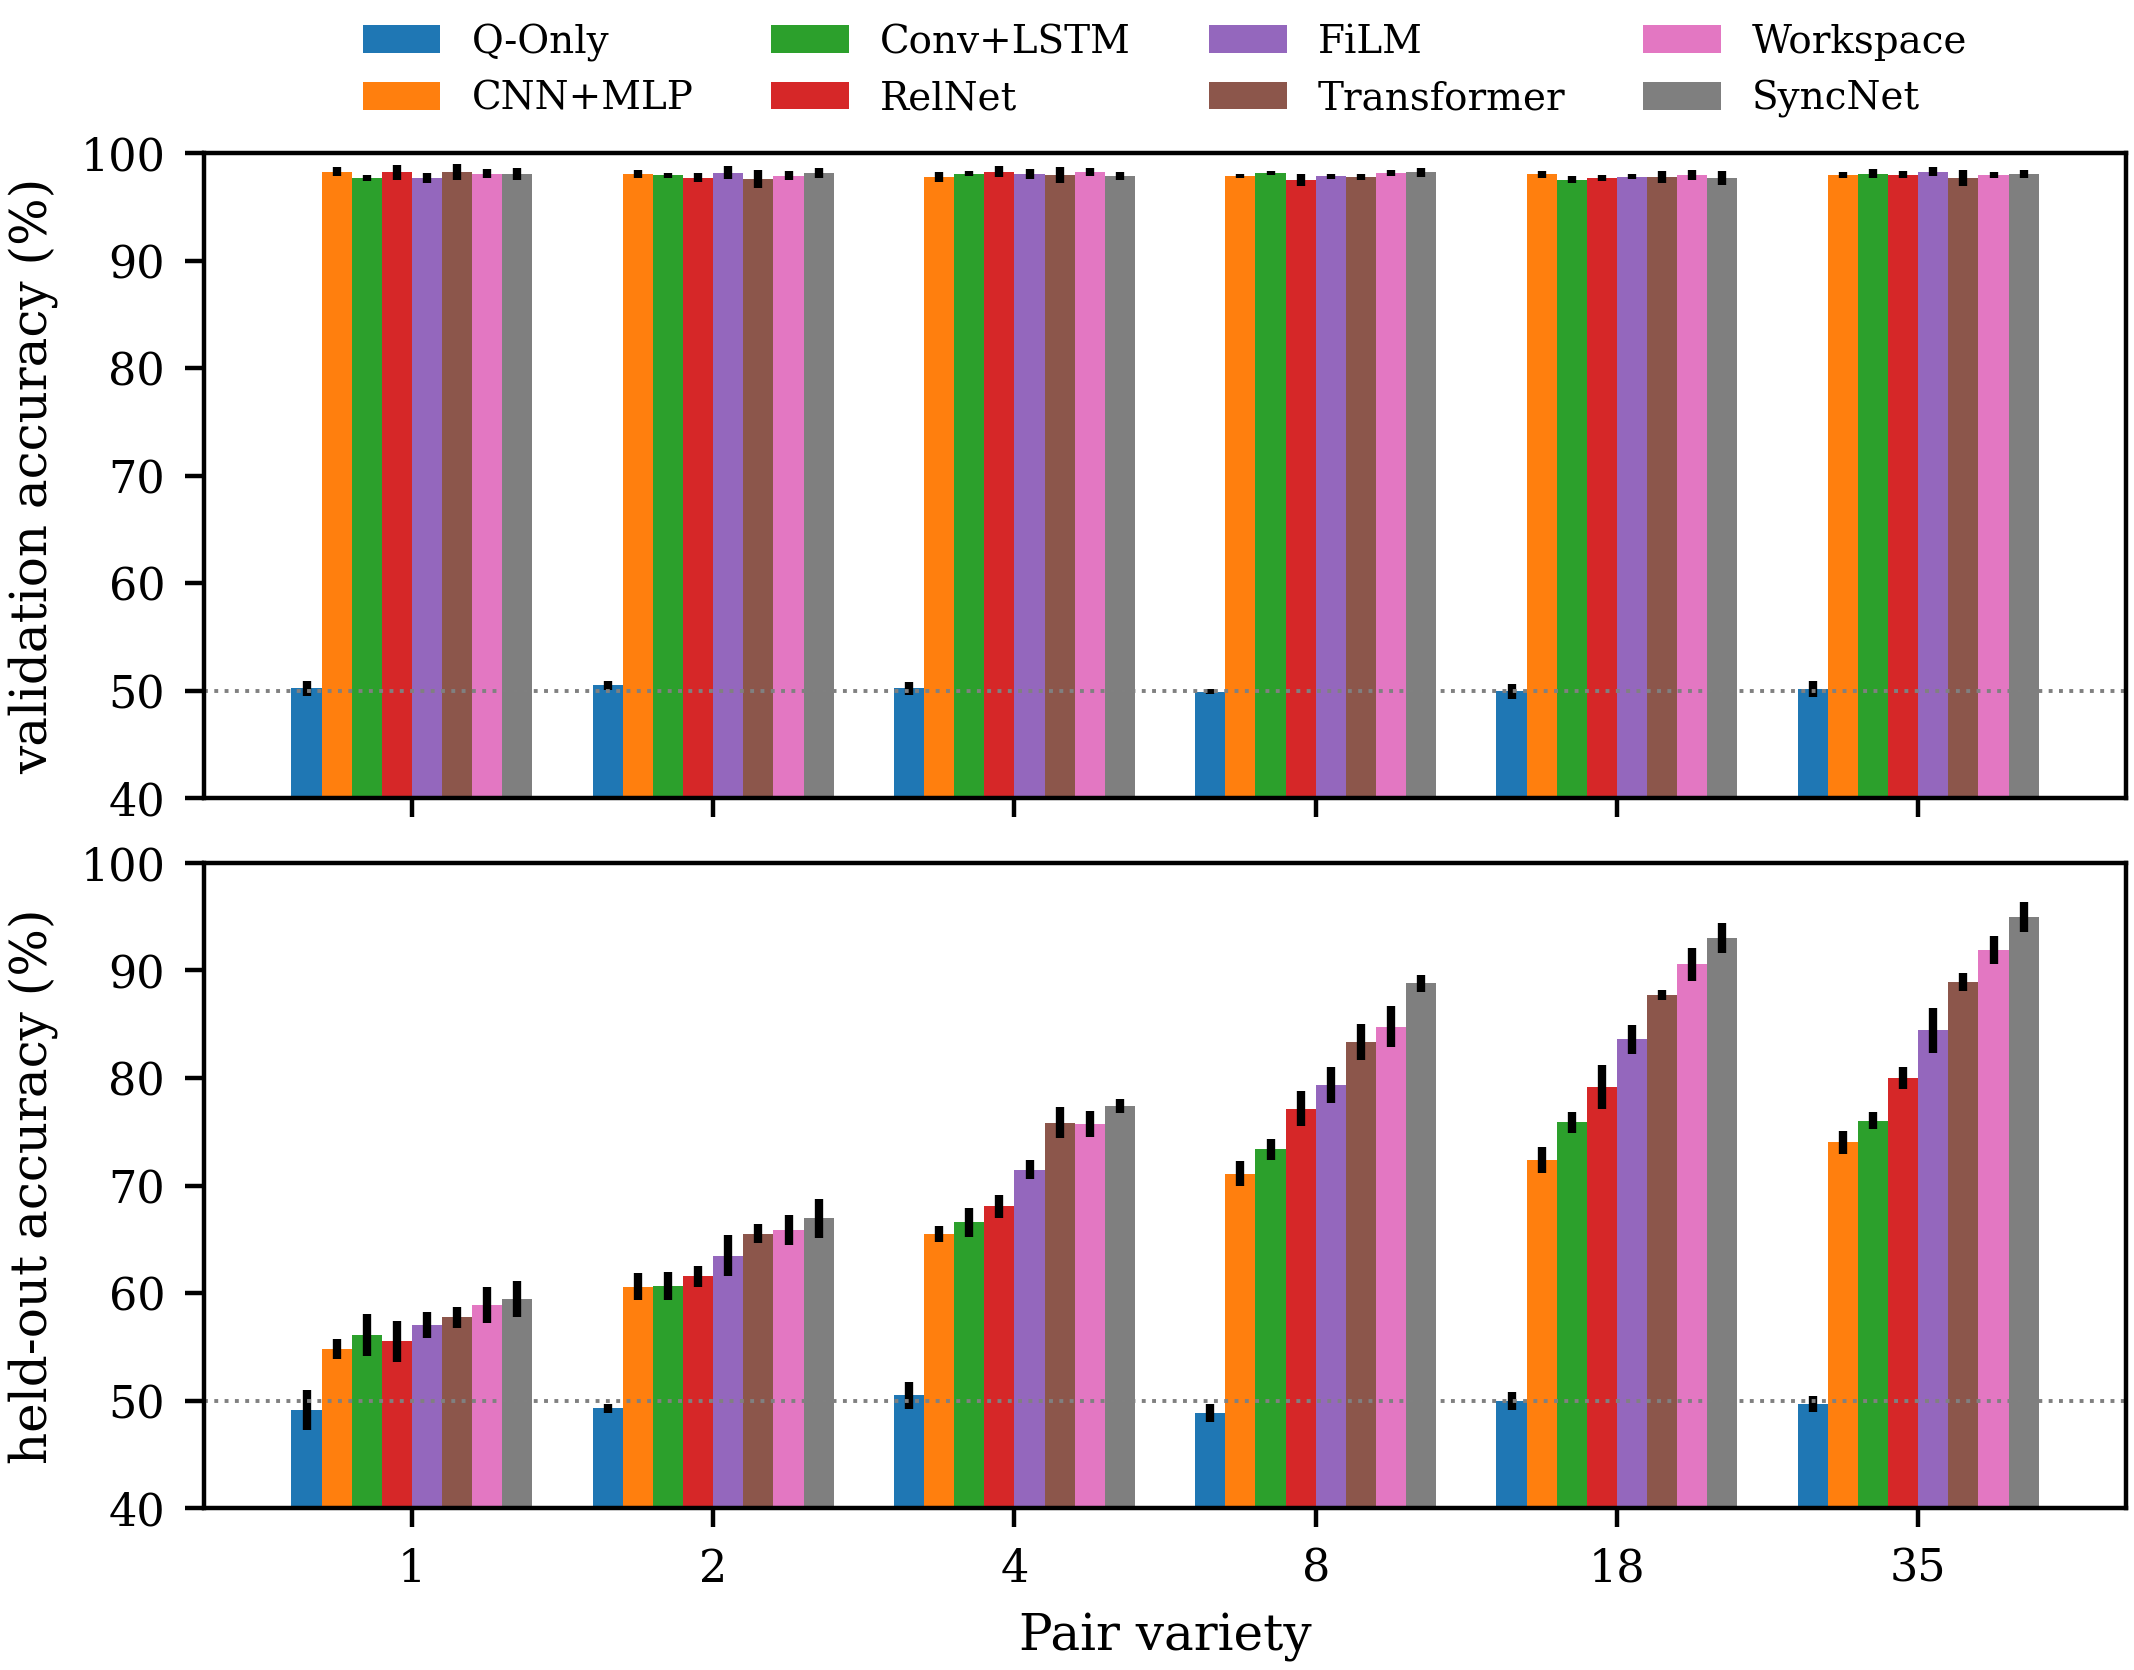

In [8]:
SQOOP_MODELS = [m for m in MAIN['sqoop'] if len(values('main', 'sqoop', m, None, 'held-out'))]

fig, axes = plt.subplots(2, 1, figsize=(6.2, 4.4), sharex=True)
x = np.arange(len(PAIR_VARIETY))
w = 0.8 / len(SQOOP_MODELS)

for ax, split in zip(axes, ['validation', 'held-out']):
    for k, name in enumerate(SQOOP_MODELS):
        ms = [mean_sd('main', 'sqoop', name, v, split) for v in PAIR_VARIETY]
        m = [a for a, _ in ms]; s = [b for _, b in ms]
        ax.bar(x + (k - len(SQOOP_MODELS) / 2 + 0.5) * w, m, w, yerr=s, label=name)
    ax.axhline(50, color='grey', linestyle=':', linewidth=0.7)
    ax.set_ylim(40, 100)
    ax.set_ylabel(f'{split} accuracy (%)')

axes[-1].set_xticks(x, PAIR_VARIETY)
axes[-1].set_xlabel('Pair variety')
axes[0].legend(frameon=False, fontsize=7, ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.0))
fig.subplots_adjust(hspace=0.1)
save_show(fig, 'sqoop_results_bars_stacked', CHAP_RESULTS)

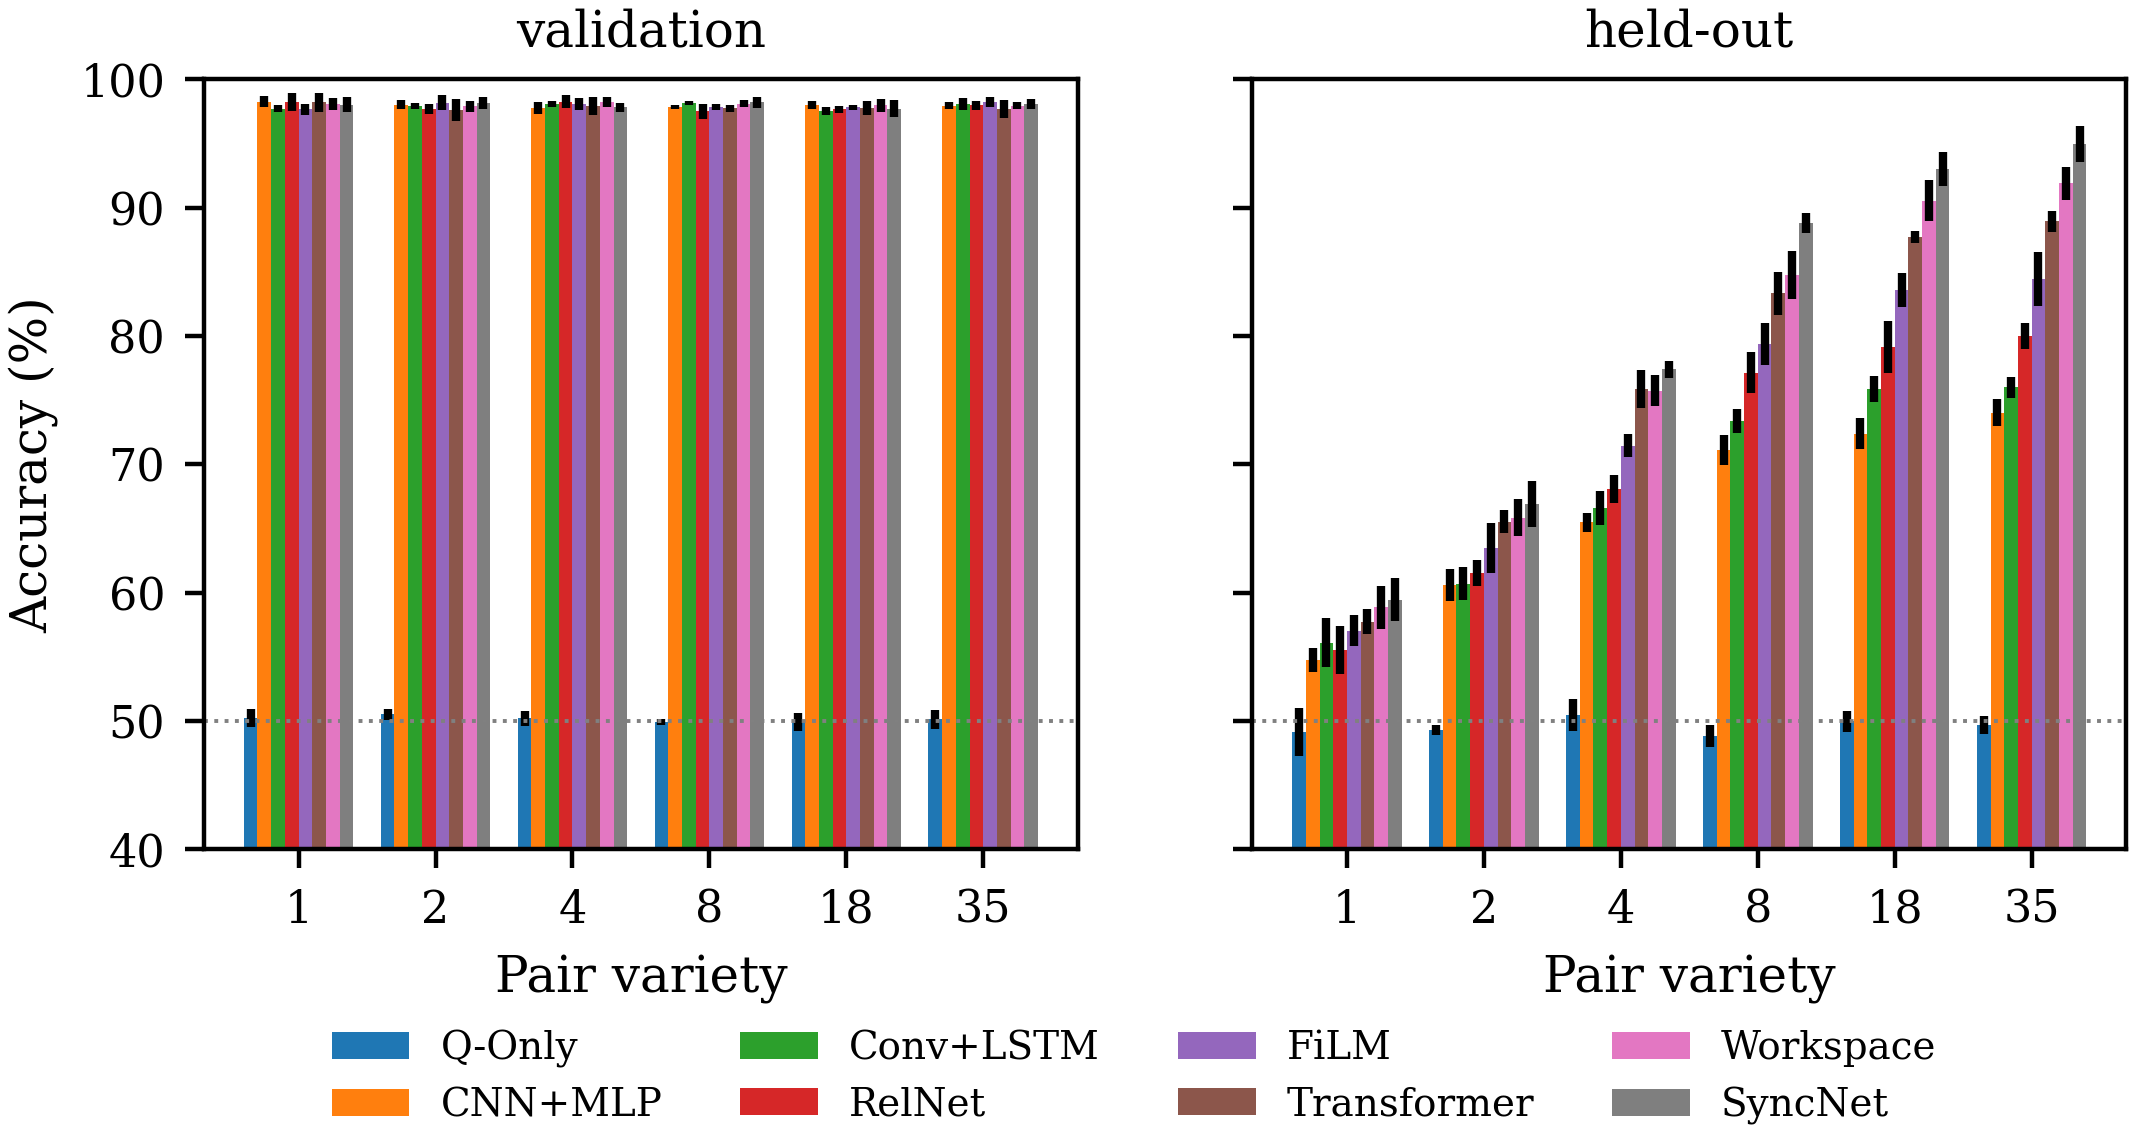

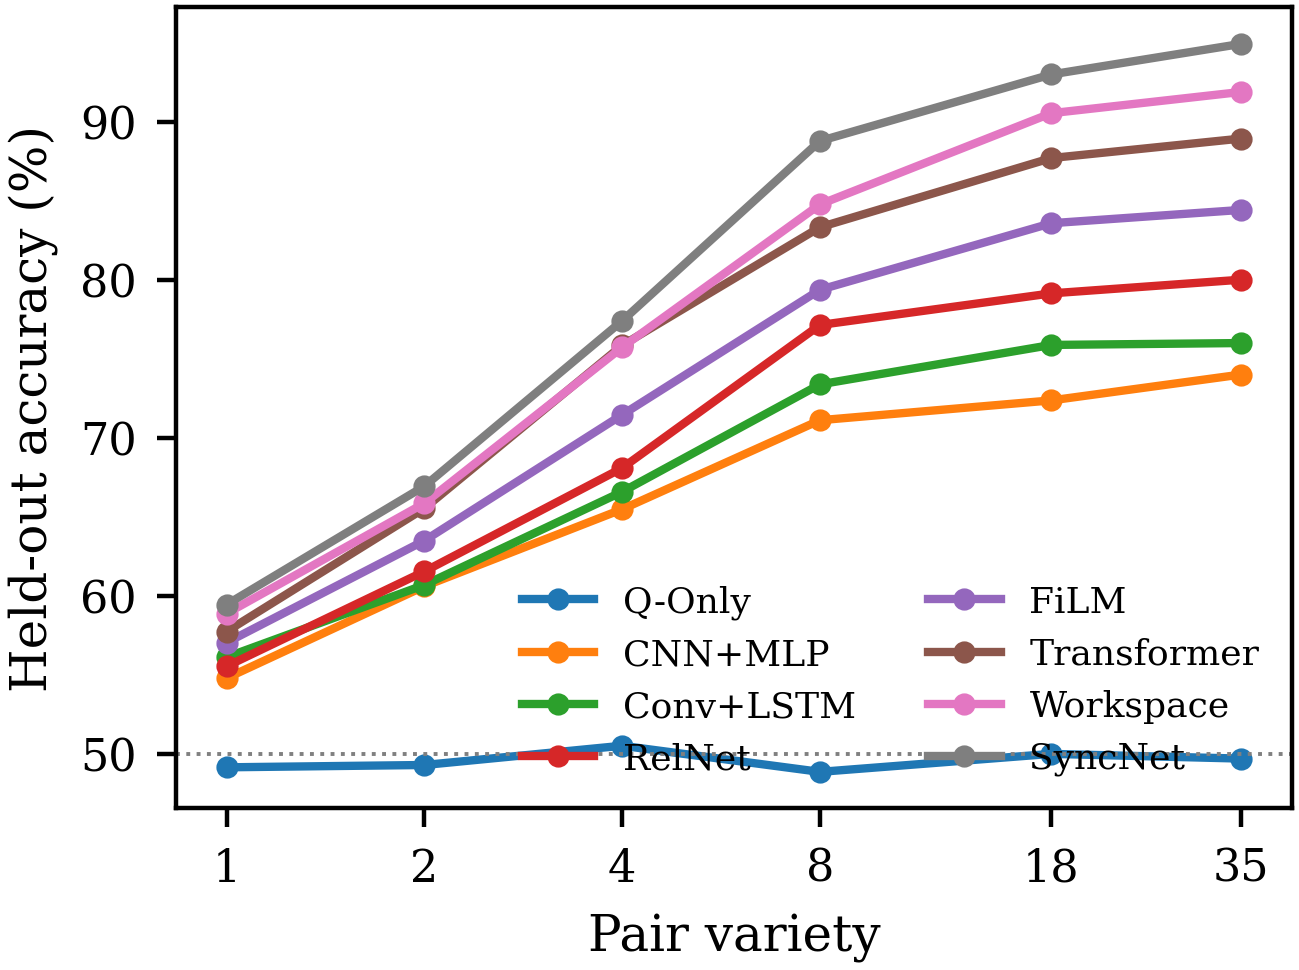

In [7]:
x = np.arange(len(PAIR_VARIETY))
w = 0.8 / len(SQOOP_MODELS)

fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.5), sharey=True)
for ax, split in zip(axes, ['validation', 'held-out']):
    for k, name in enumerate(SQOOP_MODELS):
        ms = [mean_sd('main', 'sqoop', name, v, split) for v in PAIR_VARIETY]
        m = [a for a, _ in ms]; s = [b for _, b in ms]
        ax.bar(x + (k - len(SQOOP_MODELS) / 2 + 0.5) * w, m, w, yerr=s, label=name)
    ax.axhline(50, color='grey', linestyle=':', linewidth=0.7)
    ax.set_xticks(x, PAIR_VARIETY)
    ax.set_xlabel('Pair variety')
    ax.set_title(split)
    ax.set_ylim(40, 100)
axes[0].set_ylabel('Accuracy (%)')
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, fontsize=7, ncol=4,
           loc='lower center', bbox_to_anchor=(0.5, -0.2))
save_show(fig, 'sqoop_results_bars', CHAP_RESULTS)

# alternative: held-out accuracy vs pair variety, one line per model
fig, ax = plt.subplots(figsize=(3.6, 2.6))
for name in SQOOP_MODELS:
    m = [mean_sd('main', 'sqoop', name, v, 'held-out')[0] for v in PAIR_VARIETY]
    ax.plot(PAIR_VARIETY, m, marker='o', markersize=3, label=name)
ax.axhline(50, color='grey', linestyle=':', linewidth=0.7)
ax.set_xscale('log'); ax.set_xticks(PAIR_VARIETY, PAIR_VARIETY); ax.minorticks_off()
ax.set_xlabel('Pair variety'); ax.set_ylabel('Held-out accuracy (%)')
ax.legend(frameon=False, fontsize=6.5, ncol=2, loc='lower right')
save_show(fig, 'sqoop_results_lines', CHAP_RESULTS)

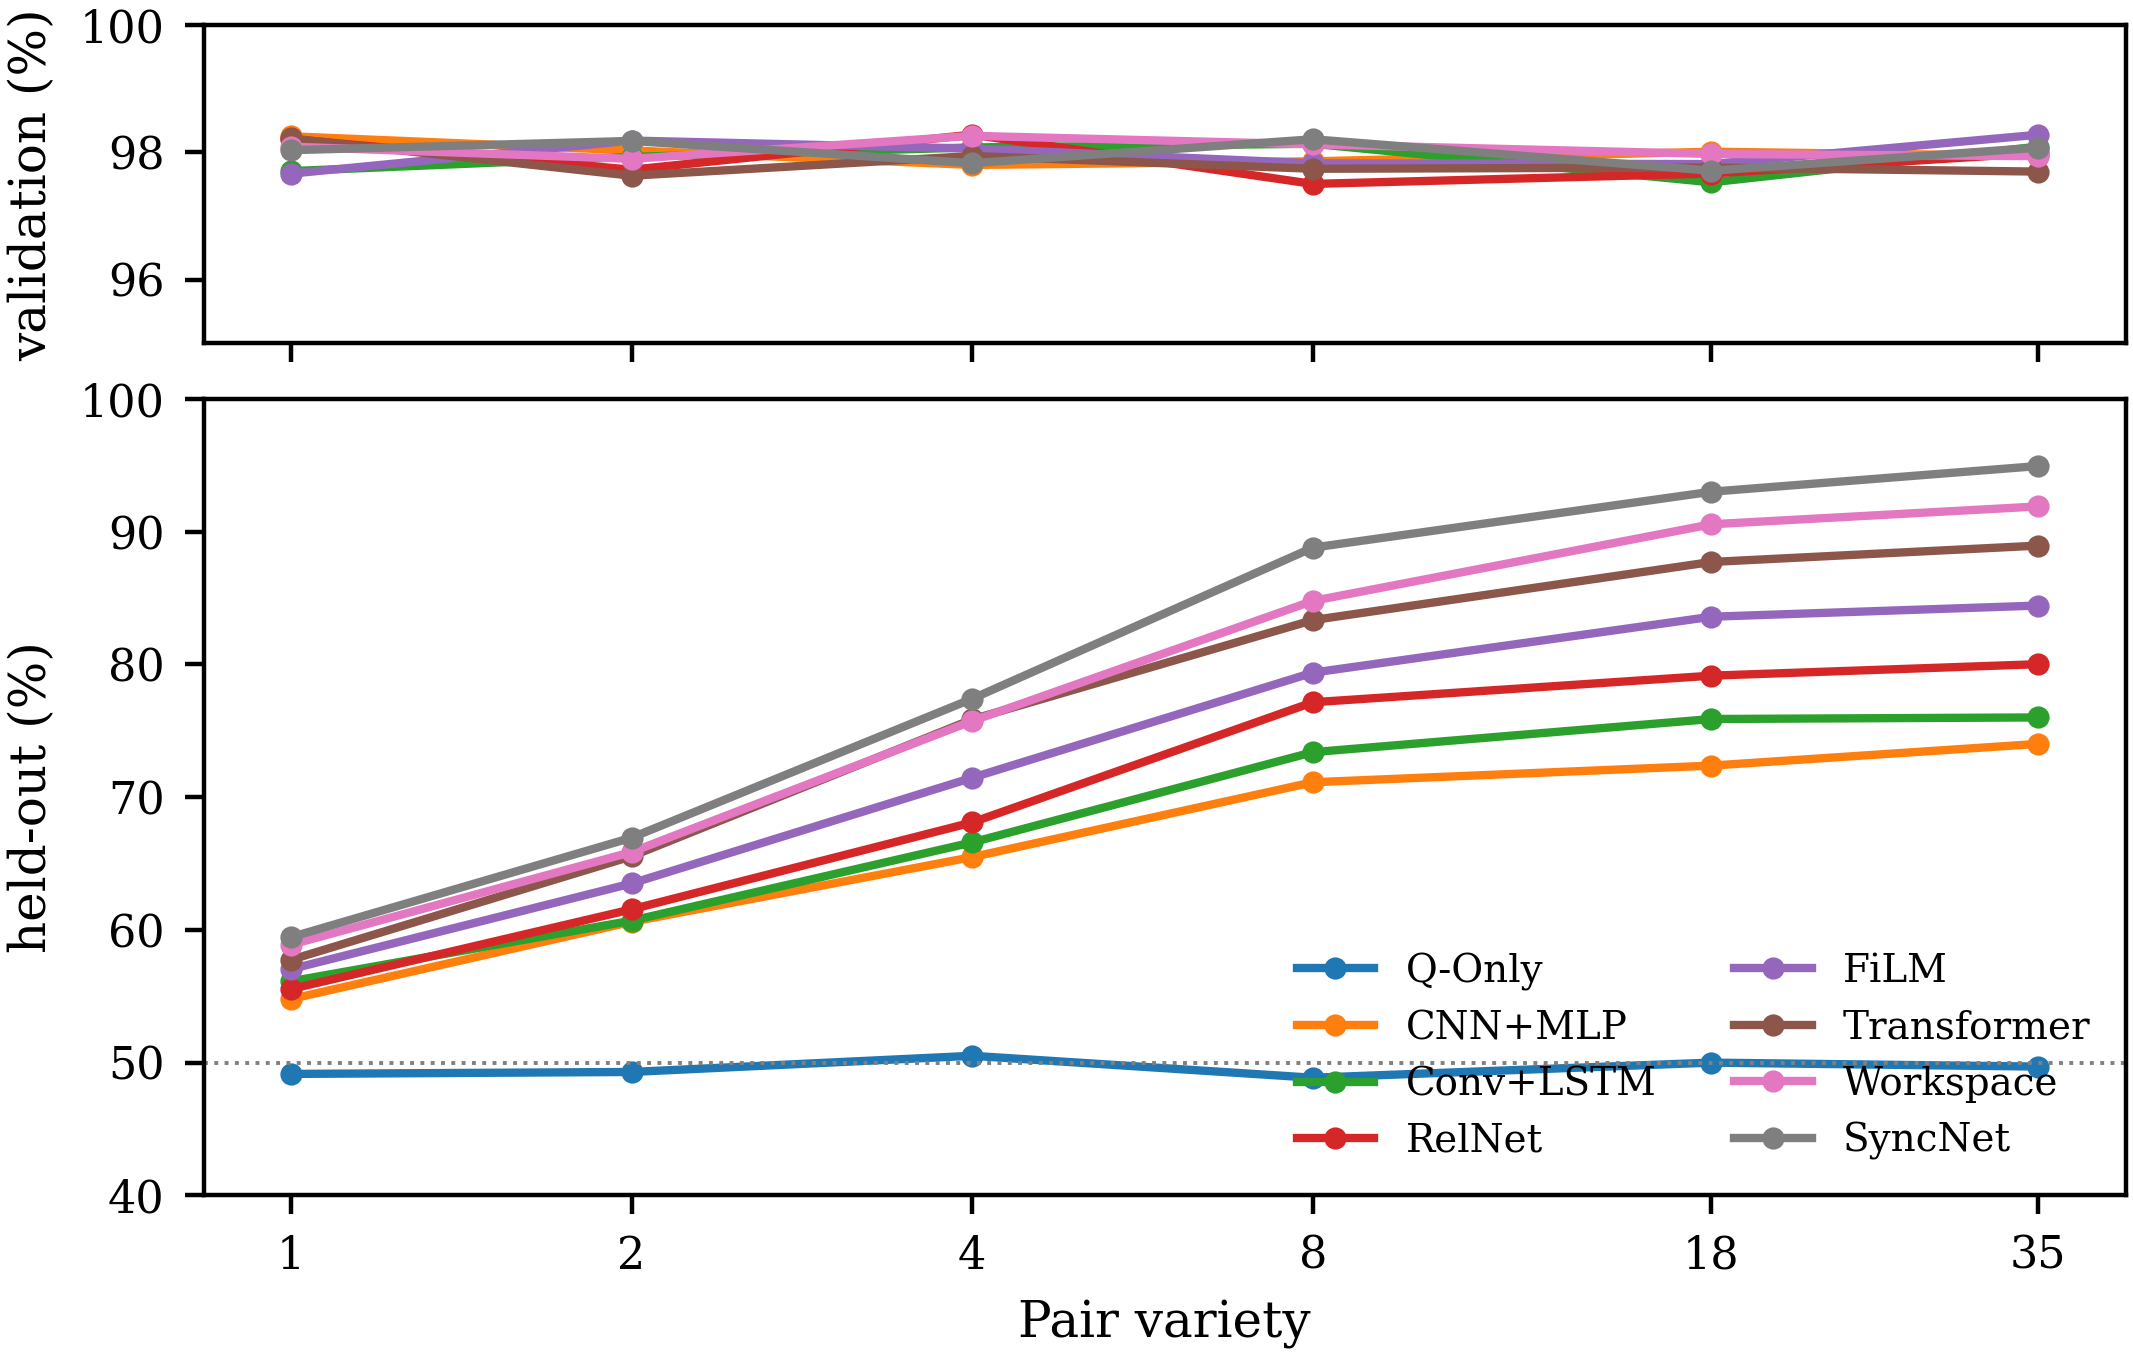

In [10]:
fig, (ax_val, ax_held) = plt.subplots(2, 1, figsize=(6.2, 3.8), sharex=True,
                                      height_ratios=[1, 2.5])
for name in SQOOP_MODELS:
    held = [mean_sd('main', 'sqoop', name, v, 'held-out')[0] for v in PAIR_VARIETY]
    val = [mean_sd('main', 'sqoop', name, v, 'validation')[0] for v in PAIR_VARIETY]
    line, = ax_held.plot(PAIR_VARIETY, held, marker='o', markersize=3, label=name)
    ax_val.plot(PAIR_VARIETY, val, marker='o', markersize=3, color=line.get_color())

ax_val.set_ylim(95, 100)
ax_val.set_ylabel('validation (%)')
ax_held.axhline(50, color='grey', linestyle=':', linewidth=0.7)
ax_held.set_ylim(40, 100)
ax_held.set_ylabel('held-out (%)')
ax_held.set_xscale('log'); ax_held.set_xticks(PAIR_VARIETY, PAIR_VARIETY); ax_held.minorticks_off()
ax_held.set_xlabel('Pair variety')
ax_held.legend(frameon=False, fontsize=7, ncol=2, loc='lower right')
fig.subplots_adjust(hspace=0.1)
save_show(fig, 'sqoop_results_lines_split', CHAP_RESULTS)